## Notebook 05c - Robustness with alternative connectivity metrics (diameter, LCC)
Núria Pascual Salas

**Content:** Validation of the connectivity measure. Repeats the fragility analysis using two alternative network metrics, diameter and the relative size of the largest connected component (LCC), on the same team networks and attack procedure used in notebook 05 (targeted PageRank-based attacks versus random removal). The resulting fragility rankings are then compared with those obtained from global efficiency. Both metrics are calculated on the undirected network. Diameter is defined as the longest shortest-path distance within the largest connected component, while LCC is the size of that component relative to the original number of nodes.

**Inputs:** fragility_per_team.csv (from notebook 05)

**Outputs:**
- outputs/csv/robustness_diameter_LCC_per_team.csv
- outputs/figures/robustness_diameter_LCC_curves.png

**Used in:** Chapter 4 (robustness check on the connectivity metric).

In [ ]:
from utils import *
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import os

FIGURES_DIR = 'outputs/figures'
CSV_DIR     = 'outputs/csv'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)

N_RANDOM_SIMS = 50  
RANDOM_SEED   = 42

### 1. Connectivity metrics: diameter and largest component size

In [2]:
def network_diameter(G):
    if G.number_of_nodes() < 2:
        return 0
    H = G.to_undirected()
    components = list(nx.connected_components(H))
    if not components:
        return 0
    largest = max(components, key=len)
    if len(largest) < 2:
        return 0
    return nx.diameter(H.subgraph(largest))


def largest_component_size(G, n_initial):
    if G.number_of_nodes() == 0:
        return 0.0
    H = G.to_undirected()
    components = list(nx.connected_components(H))
    if not components:
        return 0.0
    return len(max(components, key=len)) / n_initial

### 2. Attack functions: targeted and random degradation (diameter, LCC)


In [3]:
def targeted_attack_diameter_LCC(G):
    G_work    = G.copy()
    n_initial = G.number_of_nodes()
    diam_curve = [network_diameter(G_work)]
    s_curve    = [largest_component_size(G_work, n_initial)]

    while G_work.number_of_nodes() > 1:
        try:
            pr = nx.pagerank(G_work, weight='weight')
        except nx.PowerIterationFailedConvergence:
            break
        most_central = max(pr, key=pr.get)
        G_work.remove_node(most_central)
        diam_curve.append(network_diameter(G_work))
        s_curve.append(largest_component_size(G_work, n_initial))

    # Append final 0 if reduced below 1 node
    while len(diam_curve) <= n_initial:
        diam_curve.append(0)
        s_curve.append(0.0)
    return diam_curve, s_curve


def random_attack_diameter_LCC(G, n_simulations=50, seed=42):
    n_initial = G.number_of_nodes()
    rng = np.random.default_rng(seed)
    all_diam = []
    all_s    = []

    for _ in range(n_simulations):
        G_work = G.copy()
        diam_curve = [network_diameter(G_work)]
        s_curve    = [largest_component_size(G_work, n_initial)]
        nodes_order = list(G_work.nodes())
        rng.shuffle(nodes_order)
        for node in nodes_order:
            if G_work.has_node(node):
                G_work.remove_node(node)
            diam_curve.append(network_diameter(G_work))
            s_curve.append(largest_component_size(G_work, n_initial))
        all_diam.append(diam_curve)
        all_s.append(s_curve)

    return list(np.mean(all_diam, axis=0)), list(np.mean(all_s, axis=0))

### 3. Degrade each team's network and compute fragility (diameter, LCC)

In [4]:
results = []
curves_by_team = {}

for team_id, team_name in all_teams.items():
    print(f"Computing diameter/LCC robustness for {team_name}...")
    G, n_matches = build_consolidated_network(team_id, team_name, zip_path, folder_laliga)
    if G.number_of_nodes() < 5:
        print(f"  Skipped (network too small)")
        continue

    diam_t, lcc_t = targeted_attack_diameter_LCC(G)
    diam_r, lcc_r = random_attack_diameter_LCC(G, n_simulations=N_RANDOM_SIMS,
                                              seed=RANDOM_SEED)

    n = min(len(diam_t), len(diam_r))
    # Area between curves (random - targeted), normalised by length
    fragility_diameter = np.trapz(np.array(diam_r[:n]) - np.array(diam_t[:n])) / n
    fragility_LCC        = np.trapz(np.array(lcc_r[:n])    - np.array(lcc_t[:n]))    / n

    results.append({
        'team':                team_name,
        'team_id':             team_id,
        'n_nodes':             G.number_of_nodes(),
        'fragility_diameter':  round(fragility_diameter, 4),
        'fragility_LCC':         round(fragility_LCC, 4),
    })
    curves_by_team[team_name] = {
        'diam_targeted': diam_t, 'diam_random': diam_r,
        'lcc_targeted':    lcc_t,    'lcc_random':    lcc_r,
    }
    print(f"  Done | n={G.number_of_nodes()} | d_frag={fragility_diameter:+.3f} | LCC_frag={fragility_LCC:+.4f}")

df_results = pd.DataFrame(results).sort_values('fragility_LCC', ascending=False).reset_index(drop=True)
df_results.to_csv(f'{CSV_DIR}/robustness_diameter_LCC_per_team.csv', index=False)
print()
print(df_results.to_string(index=False))

Computing diameter/LCC robustness for Deportivo Alavés...
  Done | n=29 | d_frag=+0.086 | LCC_frag=+0.0570
Computing diameter/LCC robustness for Granada...
  Done | n=40 | d_frag=-0.800 | LCC_frag=+0.0813
Computing diameter/LCC robustness for Barcelona...
  Done | n=29 | d_frag=-0.749 | LCC_frag=+0.0114
Computing diameter/LCC robustness for Almería...
  Done | n=35 | d_frag=-0.785 | LCC_frag=+0.0289
Computing diameter/LCC robustness for Sevilla...
  Done | n=35 | d_frag=-0.426 | LCC_frag=+0.0179
Computing diameter/LCC robustness for Cádiz...
  Done | n=33 | d_frag=-0.592 | LCC_frag=+0.0290
Computing diameter/LCC robustness for Girona...
  Done | n=25 | d_frag=-0.216 | LCC_frag=+0.0359
Computing diameter/LCC robustness for Athletic Club...
  Done | n=27 | d_frag=-0.124 | LCC_frag=+0.0157
Computing diameter/LCC robustness for Real Sociedad...
  Done | n=31 | d_frag=-0.059 | LCC_frag=+0.0334
Computing diameter/LCC robustness for Mallorca...
  Done | n=25 | d_frag=-0.049 | LCC_frag=+0.0251

### 4. Compare with the efficiency-based fragility (notebook 05)

In [10]:
df_eff = pd.read_csv(f'{CSV_DIR}/fragility_per_team.csv')
df_eff = df_eff.rename(columns={'fragility': 'fragility_efficiency'})

df_merged = df_results.merge(df_eff[['team', 'fragility_efficiency']], on='team')

r_diam, p_diam = pearsonr(df_merged['fragility_diameter'], df_merged['fragility_efficiency'])
r_LCC,    p_LCC    = pearsonr(df_merged['fragility_LCC'],        df_merged['fragility_efficiency'])
r_dLCC,   p_dLCC   = pearsonr(df_merged['fragility_diameter'], df_merged['fragility_LCC'])

print(f"Comparison of specifications across robustness measures (n = {len(df_merged)}):")
print(f"  Efficiency vs Diameter: r = {r_diam:+.3f}, p = {p_diam:.4f}")
print(f"  Efficiency vs LCC:        r = {r_LCC:+.3f}, p = {p_LCC:.4f}")
print(f"  Diameter   vs LCC:        r = {r_dLCC:+.3f}, p = {p_dLCC:.4f}")

Comparison of specifications across robustness measures (n = 20):
  Efficiency vs Diameter: r = +0.015, p = 0.9490
  Efficiency vs LCC:        r = +0.935, p = 0.0000
  Diameter   vs LCC:        r = +0.189, p = 0.4254


### 5. Visualization: degradation curves for representative teams

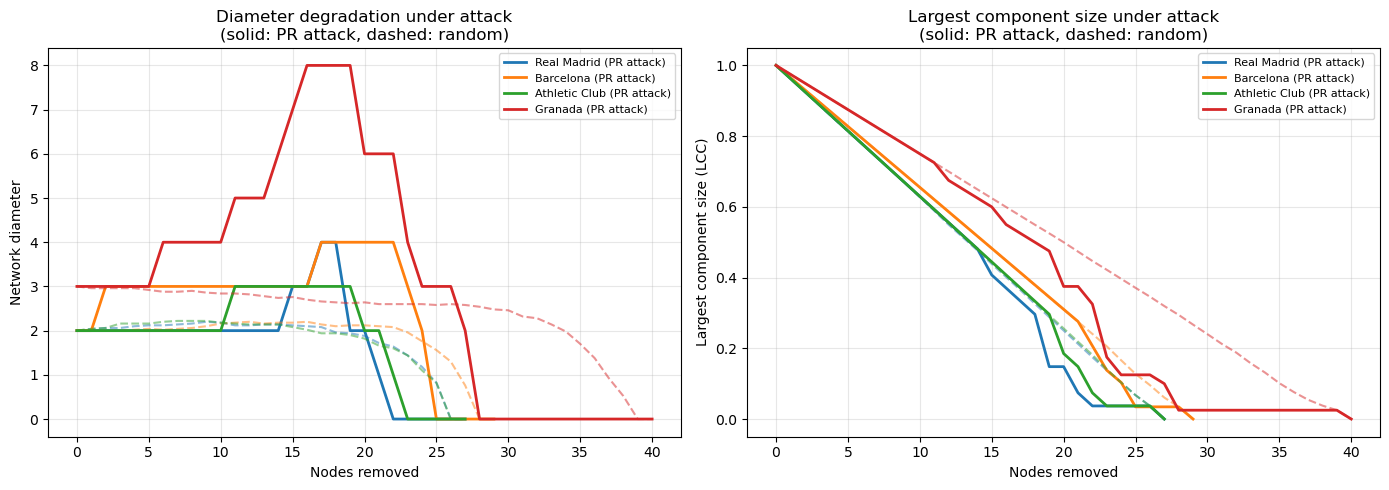

In [8]:
teams_to_plot = ['Real Madrid', 'Barcelona', 'Athletic Club', 'Granada']
teams_to_plot = [t for t in teams_to_plot if t in curves_by_team]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.tab10.colors

for i, team in enumerate(teams_to_plot):
    c = curves_by_team[team]
    x = np.arange(len(c['diam_targeted']))
    color = colors[i]
    axes[0].plot(x, c['diam_targeted'], color=color, linewidth=2,
                 label=f'{team} (PR attack)')
    axes[0].plot(x, c['diam_random'],   color=color, linestyle='--', alpha=0.5)
    axes[1].plot(x, c['lcc_targeted'],    color=color, linewidth=2,
                 label=f'{team} (PR attack)')
    axes[1].plot(x, c['lcc_random'],      color=color, linestyle='--', alpha=0.5)

axes[0].set_xlabel('Nodes removed')
axes[0].set_ylabel('Network diameter')
axes[0].set_title('Diameter degradation under attack\n(solid: PR attack, dashed: random)')
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].set_xlabel('Nodes removed')
axes[1].set_ylabel('Largest component size (LCC)')
axes[1].set_title('Largest component size under attack\n(solid: PR attack, dashed: random)')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/robustness_diameter_LCC_curves.png',
            dpi=130, bbox_inches='tight')
plt.show()

### Summary

In [11]:
print("=" * 70)
print("SUMMARY - Robustness measures (diameter and LCC)")
print("=" * 70)
print()
print(f"Comparison of specifications (n = {len(df_merged)}):")
print(f"  Efficiency vs Diameter: r = {r_diam:+.3f}, p = {p_diam:.4f}")
print(f"  Efficiency vs LCC:        r = {r_LCC:+.3f}, p = {p_LCC:.4f}")
print(f"  Diameter   vs LCC:        r = {r_dLCC:+.3f}, p = {p_dLCC:.4f}")
print()

SUMMARY - Robustness measures (diameter and LCC)

Comparison of specifications (n = 20):
  Efficiency vs Diameter: r = +0.015, p = 0.9490
  Efficiency vs LCC:        r = +0.935, p = 0.0000
  Diameter   vs LCC:        r = +0.189, p = 0.4254

